# Module 2: Cyber Threat Landscape, Data Sources, Pre-processing, and First ML Model

---

## 1. Learning Objectives

By the end of this module, you will be able to:

- Map major cyberattack types (malware, phishing, DDoS, insider threats) onto the **Cyber
  Kill Chain** and **MITRE ATT&CK**.
- Compare the major public security datasets and say which one fits a given problem.
- Apply the **machine learning workflow** end to end: framing, cleaning, feature
  engineering, modelling, evaluation.
- Clean a genuinely messy log — duplicates, missing values, corrupt entries, inconsistent
  capitalisation, and values that are physically impossible.
- Engineer features from raw logs that a model can actually use.
- Train and evaluate your first classifier, a **Logistic Regression**, and read a
  classification report and confusion matrix.
- **Recognise a result that is too good to be true, and diagnose why.** You will train a
  model that scores a perfect 100% and then prove it learned nothing worth having.
- **Act on an audit rather than just performing one** — take the defects Module 1 found in
  a real dataset, fix them, and then *measure* whether fixing them changed anything.

---

---

##2. A Review of Major Cyberattack Types

Welcome to Module 2! In our first module, we established why AI is a critical tool in modern cybersecurity. Now, we're going to dive into the what and the how. We'll start by reviewing the threat landscape, the real-world attacks that security professionals work to detect and prevent every single day.

In cybersecurity, we're constantly facing a diverse and evolving set of threats. These aren't random, isolated events; they are often part of structured campaigns carried out by adversaries with specific goals. To build effective AI-driven defenses, we must first understand the nature of the attacks we are trying to stop. Let's briefly review some of the most common and impactful categories.

---

###Malware (Malicious Software)

This is any software intentionally designed to cause disruption, damage, or gain unauthorized access to a computer system.

* Common Forms: Ransomware (encrypts files for a ransom), Trojans (disguised as legitimate software), Viruses (attach to other files), and Spyware (secretly gathers information).

---

###Phishing & Social Engineering

These attacks focus on deceiving individuals into divulging sensitive information or performing actions that compromise security.

* Common Methods: Credential Harvesting (fake login pages), Business Email Compromise (impersonating executives), and Spear Phishing (highly targeted, personalized emails).

---

###Denial-of-Service (DoS/DDoS) Attacks

The goal is to make an online service unavailable by overwhelming it with traffic, often using a "botnet" of compromised devices.

* Primary Goal: Disrupting service availability for legitimate users.

---

###Man-in-the-Middle (MitM) Attacks

Attackers secretly intercept and potentially alter communications between two parties who believe they are communicating directly.

* Common Vectors: Eavesdropping on unsecured public Wi-Fi, DNS spoofing.

---

###Web Application Attacks

These attacks exploit vulnerabilities in the code of websites and online applications.

* Key Examples: SQL Injection (manipulating database queries to steal or corrupt data) and Cross-Site Scripting (XSS) (injecting malicious scripts into trusted websites).

---

###Insider Threats

This is a threat originating from a trusted individual within an organization, such as an employee, former employee, or contractor.

* Nature of Threat: Can be malicious (intentional sabotage or data theft) or accidental (unintentional human error leading to a data leak).



---

##3. Structuring the Attack: The Cyber Kill Chain & MITRE ATT&CK

These examples might seem chaotic and unrelated, but attackers often use a predictable sequence of actions. To help defenders understand this process, security professionals use frameworks to model the stages of an attack. Two of the most important are the Cyber Kill Chain and the MITRE ATT&CK framework.

###The Cyber Kill Chain: A Linear View of an Attack

Developed by Lockheed Martin, the Cyber Kill Chain models an attack as a sequence of seven distinct stages. The idea is that if a defender can "break the chain" at any one of these stages, the entire attack can be stopped.

* Reconnaissance: Gathering intelligence on the target.

* Weaponization: Creating a malicious payload (e.g., malware in a PDF).

* Delivery: Transmitting the weapon to the target (e.g., via email).

* Exploitation: Triggering the weapon to exploit a vulnerability.

* Installation: Installing malware on the target system.

* Command & Control (C2): Establishing a channel for remote control.

* Actions on Objectives: The attacker achieves their goal (e.g., data theft).


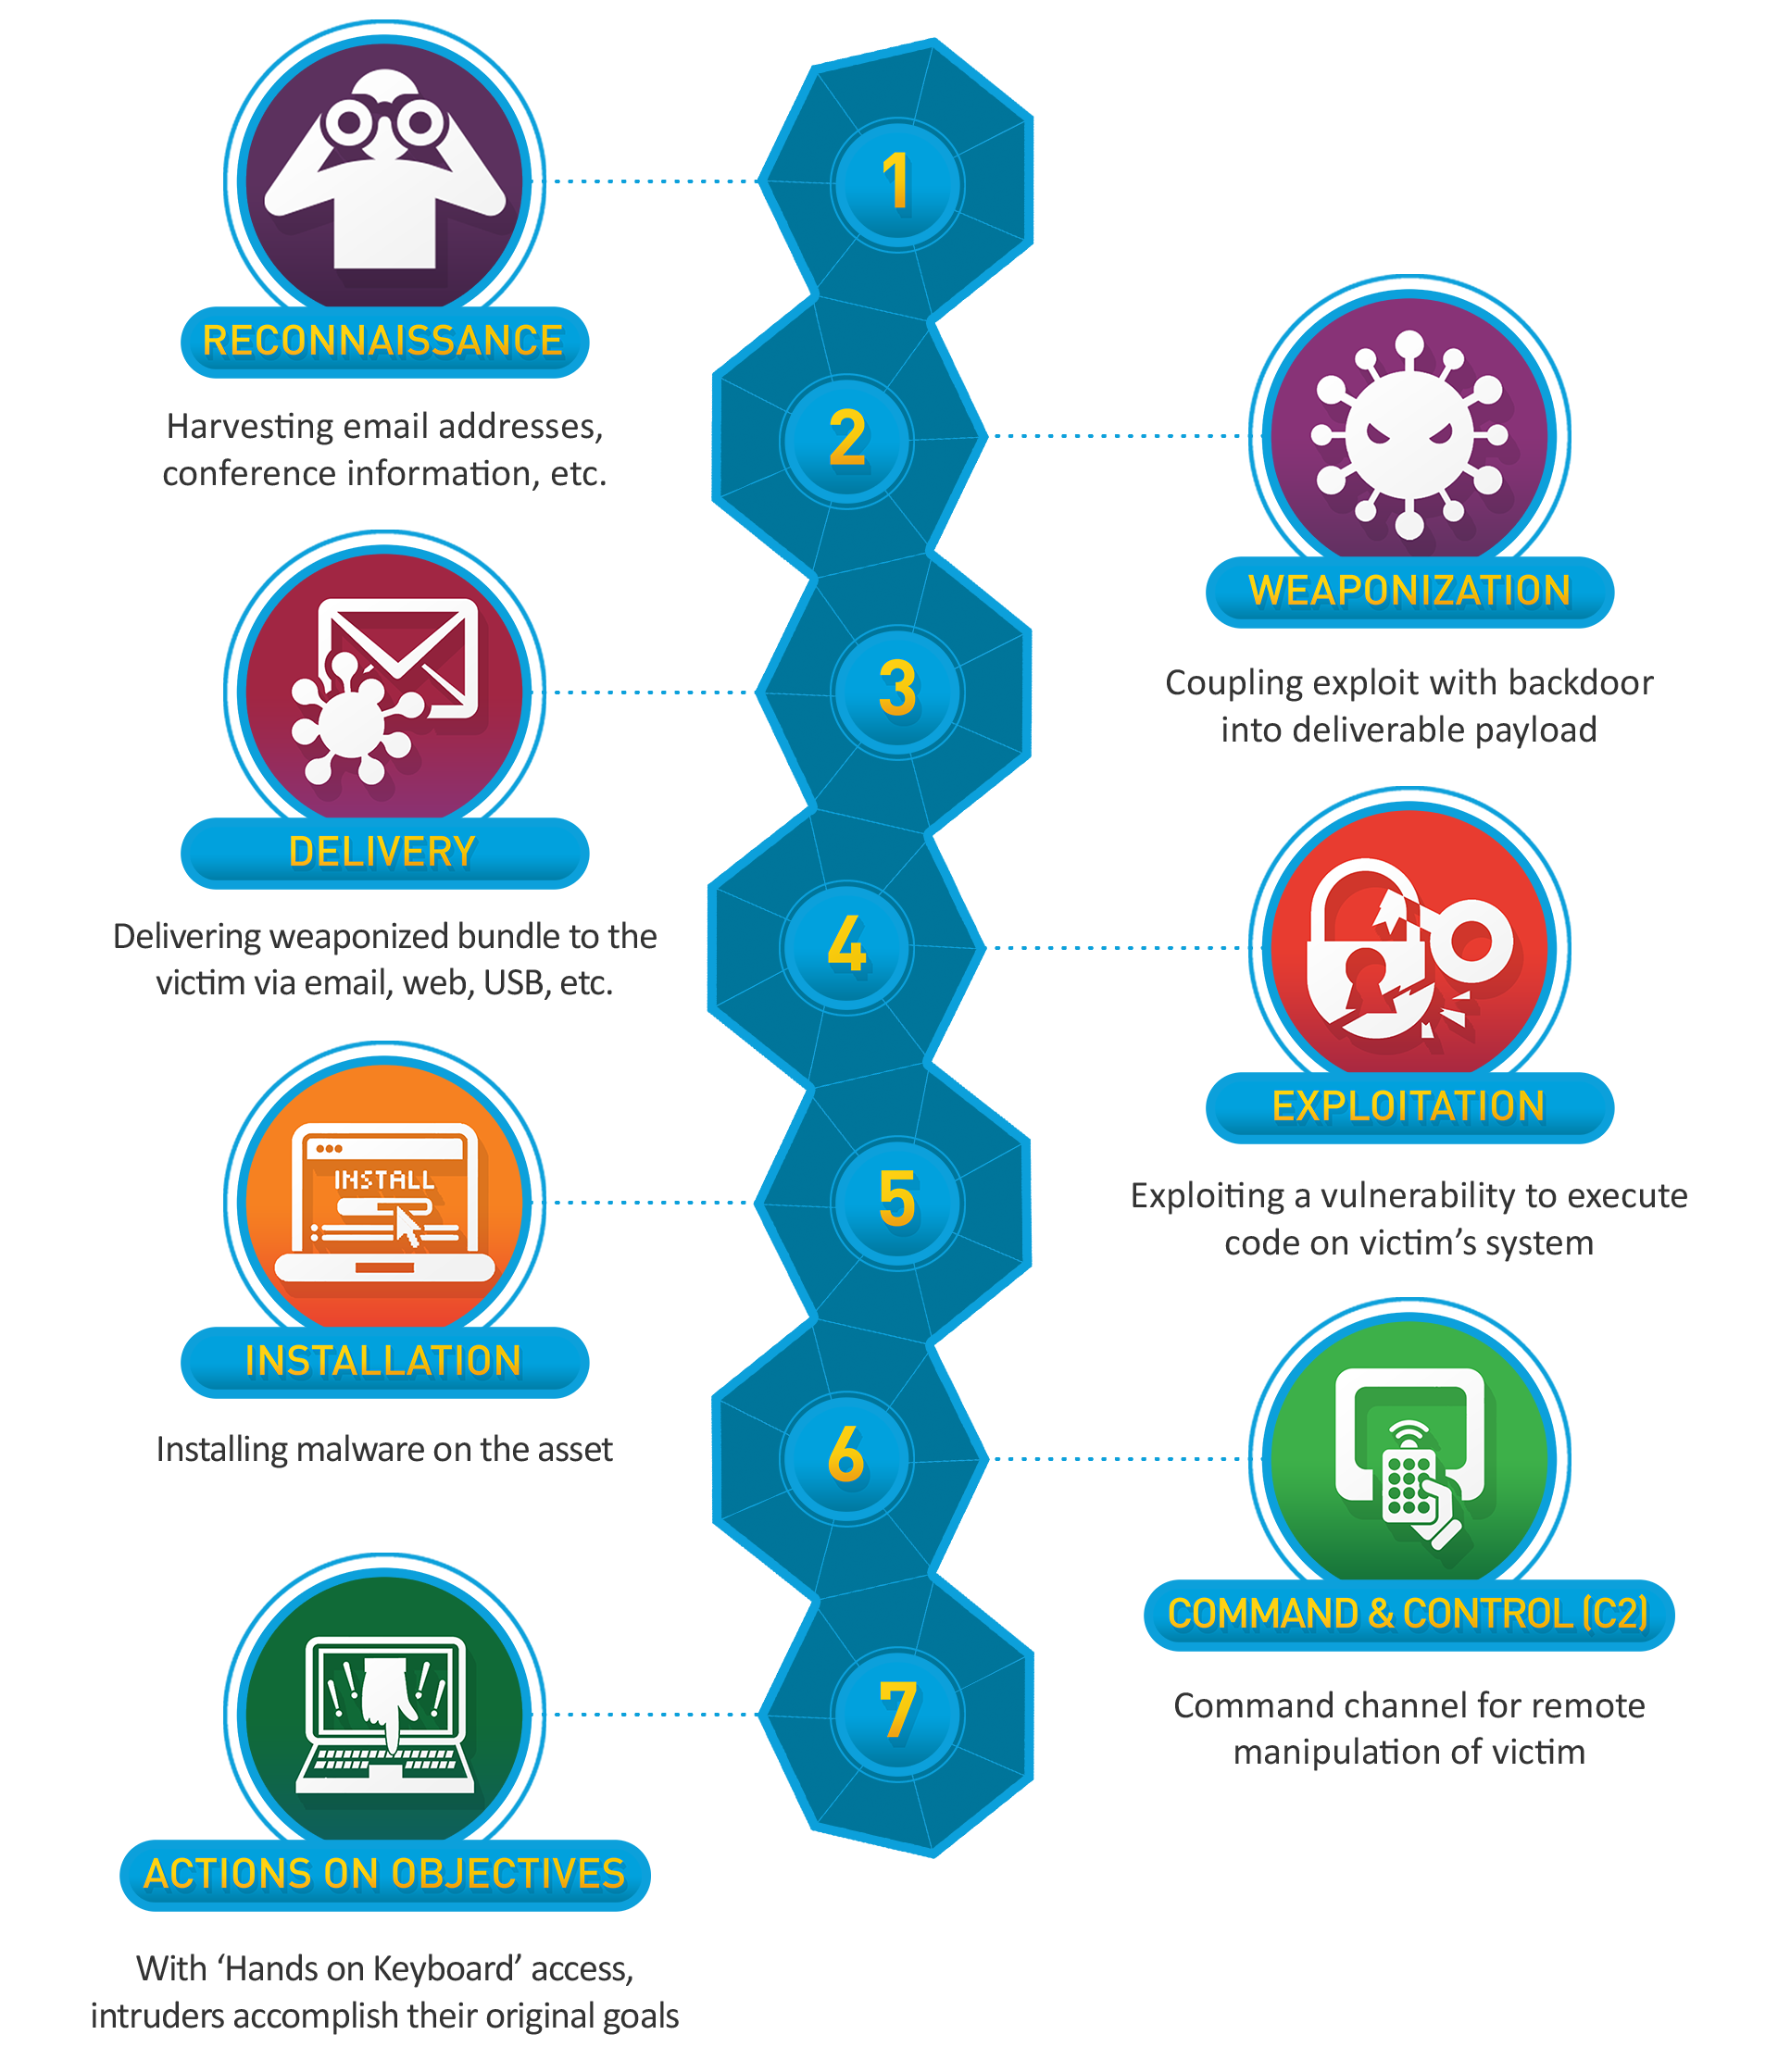

###MITRE ATT&CK: A Granular Playbook of Techniques

While the Kill Chain provides a high-level, linear path, the MITRE ATT&CK framework offers a much more detailed and flexible view. It’s a globally-accessible knowledge base of adversary tactics (the "why") and techniques (the "how") based on real-world observations. Instead of one single path, ATT&CK is a matrix of possibilities, showing the many different ways an attacker might achieve a goal like "Initial Access" or "Privilege Escalation." It acts as a common language for the global security community to describe how attackers operate.


---

###Example Framework:

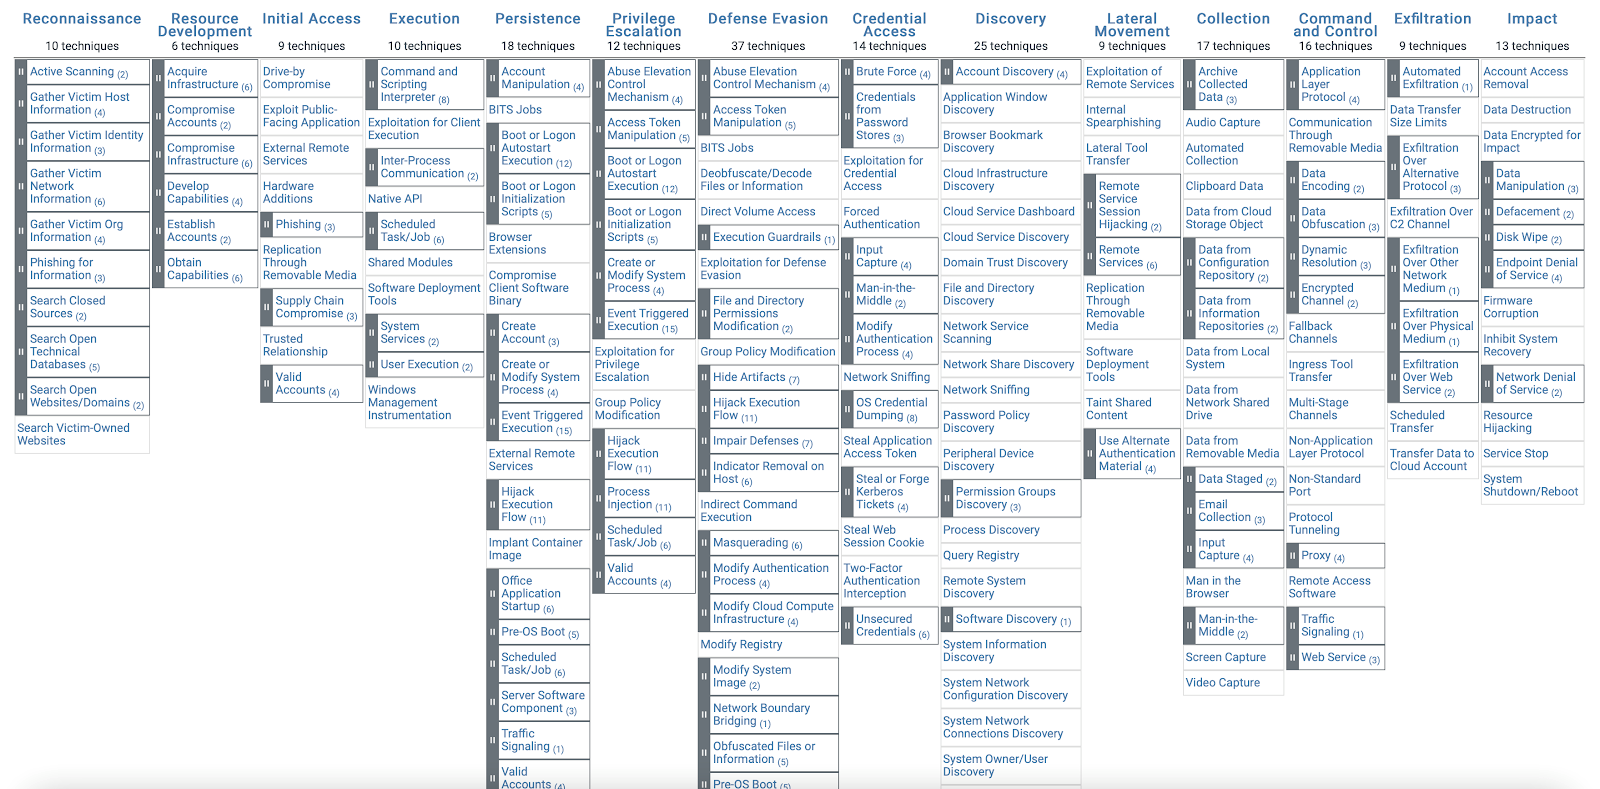

##4. Cyber Threat Landscape
Now that we've reviewed the threat landscape and the conceptual frameworks used to understand it, let's dive deeper into the specific tools and data sources that will form the foundation of our hands-on work. In this section, we'll explore the MITRE ATT&CK framework in more detail and introduce the real-world datasets we will use to train our first machine learning models.

###Deeper Dive: The MITRE ATT&CK Framework

We briefly introduced MITRE ATT&CK as a playbook of adversary actions. Let's break down its structure. The framework is built around three core concepts known as TTPs:

* Tactics: These represent the adversary's high-level technical goals. They are the "why" behind an attacker's action. Examples include Initial Access, Execution, Persistence, and Exfiltration. There are 14 tactics in the Enterprise ATT&CK Matrix.

* Techniques: These are the specific methods adversaries use to achieve a tactic. They are the "how." For the tactic of Initial Access, for example, a technique could be Phishing or Drive-by Compromise.

* Procedures: These are the specific, real-world implementations of a technique. A procedure for the Phishing technique might be "an attacker sent a spearphishing email with a malicious PDF attachment to the finance department."

These TTPs are organized into a large matrix. The columns represent the Tactics (the goal), and the rows under each tactic list the various Techniques (the method) used to achieve that goal.

###The MITRE ATT&CK Navigator

To make this vast amount of information usable, MITRE provides a free web-based tool called the ATT&CK Navigator. It allows security teams to visualize the ATT&CK matrix, create heatmaps of observed adversary behavior, and plan defensive coverage. For example, you can use it to map out all the known techniques used by a specific threat group (like APT28) to better understand their methods and prioritize your defenses.

#Optional Activity

**Activity**: Follow the document and complete the activity for comparing layers in Att&ck Navigator: https://mitre-attack.github.io/attack-navigator/

Activity PDF: https://attack.mitre.org/docs/training-cti/Comparing%20Layers%20in%20Navigator.pdf


Submission instructions:

A. Identify one Technique that is unique to APT39 and one that is unique to OceanLotus from your comparison.

**[insert answer]**

B. After creating your combined layer, which Tactic (e.g., Initial Access, Execution) shows the most overlap in techniques between APT39 and OceanLotus?

**[insert answer]**

C. Why is it important to be able to compare the tequniques of two different groups in this manner?

**[insert answer]**

D. Based on your combined layer, if you had a limited budget and could only defend against five specific techniques, which five would you choose to maximize your coverage against both groups? Briefly explain your reasoning.

**[insert answer]**




---

##Activity: Deconstructing Attacks with ATT&CK (optional)

Goal: The purpose of this activity is to practice connecting common, high-level attack categories (like phishing and DDoS) to the specific, granular techniques listed in the MITRE ATT&CK framework. This is a critical skill for security analysts who need to deconstruct incidents and communicate their findings using a standardized language.

####Instructions:
For each scenario below, your task is to identify the specific ATT&CK Technique that corresponds to each step of the attack. Use the official MITRE ATT&CK Enterprise Matrix website to find the appropriate Tactics, Techniques, and their corresponding IDs. Fill in the provided tables with your findings.

**Scenario 1: A Phishing Campaign Leads to Malware**

An employee receives a well-crafted email that appears to be from their IT department, asking them to update their password. The employee clicks the link, enters their credentials on a fake login page, and is then redirected to a page that downloads a file named Update.exe. The employee runs the file, which installs malware that sets up a scheduled task to run every hour, ensuring it survives a reboot.

----

**Your Task: Complete the details for steps 2, 3, and 4.**

1. Attack Step: Phishing email is sent and opened.

* ATT&CK Tactic: Initial Access

* ATT&CK Technique: Phishing

* Technique ID: T1566

2. Attack Step: User's credentials are stolen.

* ATT&CK Tactic: **[insert answer]**

* ATT&CK Technique: **[insert answer]**

* Technique ID: **[insert answer]**

3. Attack Step: User is tricked into running Update.exe.

* ATT&CK Tactic: **[insert answer]**

* ATT&CK Technique: **[insert answer]**

* Technique ID: **[insert answer]**

4. Attack Step: Malware creates a scheduled task.

* ATT&CK Tactic: **[insert answer]**

* ATT&CK Technique: **[insert answer]**

* Technique ID: **[insert answer]**

---

**Scenario 2: A Distributed Denial-of-Service (DDoS) Attack**

A company's e-commerce website suddenly becomes unavailable. Investigation reveals that the web servers are being flooded with an overwhelming number of requests from thousands of different IP addresses around the world, saturating the network connection and exhausting server resources.

**Your Task: Complete the details for the attack step.**

1. Attack Step: Web server is flooded with traffic.

* ATT&CK Tactic: **[insert answer]**

* ATT&CK Technique: **[insert answer]**

* Technique ID: **[insert answer]**

---

**Activity Follow-Up Questions**

Please answer the following questions based on your research.

Comparing Goals: Looking at the Tactics you identified, what is the fundamental difference in the ultimate goal between the attack in Scenario 1 and the attack in Scenario 2?

**[insert answer]**

Defensive Prioritization: In Scenario 1, an attacker had to succeed at multiple steps to achieve their goal. If you were a security analyst and could only implement a new monitoring capability for one of the techniques you identified, which one would you choose to detect? Justify your choice.

**[insert answer]**

---

###The "Why": How Frameworks Guide Our Machine Learning

You have just been introduced to two of the most important conceptual models in all of cybersecurity: the Cyber Kill Chain and the MITRE ATT&CK framework.

At this point, you are probably asking a very fair question: "This is an AI-cyber course. Why am I learning this high-level theory?"

* **The answer is simple:** These frameworks are the 'blueprints' that tell us what to look for. Our machine learning models are the 'tools' we will build to how we find them.

**This connection is the single most important concept in this course.**

####From Abstract Behavior to Concrete Math

Think about it: a machine learning model (like the ones we will build) is just a complex mathematical equation. It cannot understand an abstract concept like "an attacker is establishing a command and control channel." It only understands numbers.

Our job as security data scientists is to be the translator. We must translate the abstract behaviors described in the frameworks into concrete, numerical features that a model can process.


* This translation process is called **Feature Engineering**.


Let's use a real example:

**1. The Frameworks Define the Behavior:**

* MITRE ATT&CK tells us an attacker uses technique T1566.002 - Spearphishing Link. This is the what.

**2. We Form a Hypothesis:**

* We ask ourselves, "What does that behavior actually look like in our data? What's the evidence?"

* We hypothesize: "A malicious phishing link probably looks 'weird' to bypass filters. It might be unusually long, have a lot of random-looking subdomains (lots of dots), or even try to hide an IP address in the URL."

**3. Feature Engineering Translates Behavior into Math:**

* This is the how. We turn our hypothesis into code. In our upcoming labs, we will create features like:

```
length_url

qty_dot_url

domain_in_ip
```

* These features are the mathematical proxies for the attacker's TTP.**

When we finally build our model, it won't be learning to find "threat_type". It will be learning that high values for certain features are strongly correlated with a malicious outcome.


**The Takeaway:**

As we move into our practical labs, don't think of the Kill Chain and ATT&CK as just theory. They are our guides. They are the "treasure maps" that tell us exactly where—and how—to start digging for threats with our data.

---

###From Frameworks to Data

By using these frameworks, we can understand what digital evidence to look for at each stage of an attack. And to find that evidence, we need data, lots of it. Security professionals and researchers have curated powerful datasets from real-world network traffic and security events. Datasets like CICIDS2017 (for network intrusion detection), PhishTank (for phishing URLs), and EMBER (for malware) are the raw materials we will use to train our AI models.

This leads us to the core of this module: once we have the data, how do we prepare it and build our first predictive models? We'll walk through the entire workflow, from exploring raw data to building and evaluating our first models to tackle a real cybersecurity problem.


---

##5. Datasets for Cybersecurity


Machine learning models learn from data. To build effective security models, we need large, realistic datasets that accurately reflect the threats we're trying to detect.

The four below are the ones you will meet constantly in security-ML papers and job interviews. It is worth knowing what each is *for*, because choosing the wrong dataset is a mistake no amount of modelling can repair.

> **A note on what this course actually uses.** These four are the landscape, not our syllabus. This course works with a hosted phishing-URL dataset (Modules 1 and 2), credit-card fraud (Modules 4 and 5), malware binaries rendered as images, a corpus of labelled emails, generated domain names, and IoT network flows. Every one is downloaded automatically from the course repository — you will never need an account or an API token.

**CICIDS2017 / CSE-CIC-IDS2018**: These are comprehensive network intrusion detection datasets. They contain raw network traffic (packet captures) and processed network flow data that includes a wide range of simulated, real-world attacks like Brute Force, DoS/DDoS, Web Attacks, and infiltration. This is our go-to source for training models to spot malicious network behavior.

**PhishTank**: Operated by OpenDNS, PhishTank is a collaborative clearinghouse for data and information about phishing on the internet. It provides a community-verified list of phishing URLs, which is invaluable for training classifiers to distinguish malicious links from legitimate ones.

**EMBER (The Endgame Malware BEnchmark for Research)**: This is a large-scale dataset for training malware classifiers. It consists of over a million feature sets extracted from Windows Portable Executable (PE) files (i.e., .exe and .dll files). It's a critical resource for building models that can perform static analysis, judging whether a file is malicious without actually running it.

**IoT-23**: As the Internet of Things (IoT) has grown, so has its attack surface. This dataset contains network traffic from various infected and benign IoT devices, such as smart home assistants and security cameras. It's designed for developing models that can detect compromises on these low-power, high-risk devices.



###**Activity: Know Your Data - Matching Datasets to Threats**

Goal: In cybersecurity, you must select the right data to answer the right questions. This activity will help you understand the distinct purposes of our core datasets and learn to identify which one is most appropriate for a given security problem.

**Part 1: Dataset Comparison**

**Instructions:**

Research the EMBER and IoT-23 datasets to complete the details below. The first entry for CICIDS2017 has been completed for you as an example. You may need to do a quick web search to find the specifics.

* Dataset 1: CICIDS2017

* Primary Use Case: Network Intrusion Detection

* Type of Data Contained: Labeled network traffic flows (features like packet count, duration, protocol type)

* Example Threat It Helps Detect: DoS/DDoS attacks, Port Scans, Web Attacks

**Dataset 2: EMBER**

* Primary Use Case: **[insert answer]**

* Type of Data Contained: **[insert answer]**

* Example Threat It Helps Detect: **[insert answer]**

**Dataset 3: IoT-23**

* Primary Use Case: **[insert answer]**

* Type of Data Contained: **[insert answer]**

* Example Threat It Helps Detect: **[insert answer]**

**Part 2: You are the Analyst - Scenario-Based Analysis**

**Instructions:**

For each of the following scenarios, you are a security analyst tasked with investigating the incident. Identify which of the three datasets (CICIDS2017, EMBER, or IoT-23) would be the most relevant for training a machine learning model to detect this kind of threat in the future. Crucially, you must also explain why.

**Scenario A: The Sluggish Network**
A company reports that its internal network has become extremely slow. Users are complaining about lag, and the main web server has crashed twice in the last hour. You suspect an internal device might be flooding the network with malicious traffic, but you don't know which one or what kind of traffic it is.

* Most Relevant Dataset: **[insert answer]**

* Justification (Why?): **[insert answer]**

**Scenario B: The Suspicious Executable**
An employee in the finance department reports a suspicious email that contained a ZIP file with an invoice. They downloaded and extracted an executable file named invoice_printer.exe but did not run it. You have the file and need to determine if it is a known type of malware before it spreads.

* Most Relevant Dataset: **[insert answer]**

* Justification (Why?): **[insert answer]**

**Scenario C: The Rogue Camera**
A facilities manager notices that a smart security camera on the corporate network is sending an unusually large amount of data to an unknown IP address overseas. The camera is not supposed to be communicating with external servers. You need to analyze its network behavior to determine if it is part of a botnet.

* Most Relevant Dataset: **[insert answer]**

* Justification (Why?): **[insert answer]**


##6. The Machine Learning Workflow

Before we write a single line of code for our labs, it's essential to understand the bigger picture. Applying machine learning to cybersecurity isn't a magic button; it's a structured, repeatable process known as a workflow. This workflow provides a roadmap that takes us from a raw security problem to a functional, data-driven solution.

While the specific tools may change, the core steps remain consistent whether you're building a malware classifier or an intrusion detection system.

Here are the key stages of the machine learning workflow:

####**1. Problem Framing & Data Collection**

The Question: This is the most critical step. We start by defining a clear, specific security question we want to answer with data.

* Bad Question: "Can we use AI to stop hackers?" (Too vague)

* Good Question: "Can we build a model that predicts whether an incoming email is phishing or legitimate based on its headers and content?" (Specific and measurable)

* Data Sourcing: Once we have our question, we need the right data. We ask, "What digital evidence would this threat leave behind?" This leads us to the datasets we've already discussed. To answer our phishing question, we'd turn to a source like PhishTank. For network intrusion, we'd use CICIDS2017.

####**2. Data Preprocessing & Feature Engineering**

* The Reality: Real-world security data is messy, incomplete, and full of noise. It's not ready for a machine learning model "out of the box."

* The Work: This stage involves cleaning the data (handling missing values, correcting errors) and, most importantly, feature engineering. This is where our security domain knowledge becomes a superpower. We create new, meaningful features from the raw data that will help our model learn. For example, from a raw URL, we might engineer features like url_length, has_special_characters, or contains_ip_address.

####**3. Model Selection**

* The Goal: Here, we choose the right algorithm for the job based on our initial question.

* Are we classifying a known threat with labeled data (e.g., "malware" vs. "benign")? We'll select a supervised learning algorithm like Logistic Regression or a Neural Network.

* Are we trying to find novel, never-before-seen threats without labeled data? We'll choose an unsupervised learning algorithm for anomaly detection.

####**4. Model Training**

* The "Learning" Phase: This is where the magic happens. We feed our clean, preprocessed data to the selected model. The algorithm iterates through the data, identifying the complex patterns and relationships between the features we engineered and the outcomes we want to predict. The result of this process is a "trained model."

####**5. Model Evaluation**

* The Test: A trained model is useless until we can prove it works. We evaluate its performance on a separate set of data it has never seen before.

* The Metrics: In a security context, a simple "accuracy" score isn't enough. We have to ask more critical questions:

* Precision: Of all the alerts this model generated, how many were actually malicious? (Prevents "alert fatigue" for analysts).

* Recall: Of all the actual malicious events, how many did our model successfully catch? (Prevents false negatives, which can be catastrophic).

####**6. Deployment & Monitoring**

* The Real World: Once a model proves its value, it's deployed into a live environment, perhaps as part of a Security Information and Event Management (SIEM) system or an email filtering pipeline.

* The Evolution: The threat landscape is constantly changing. A model trained on today's malware might be obsolete in six months. This final step involves continuously monitoring the model's performance and having a plan to retrain it with new data to keep it effective.

---

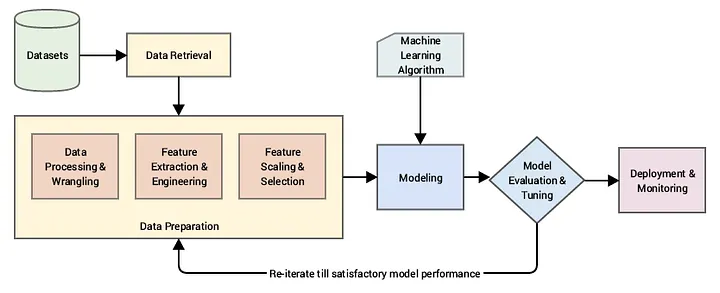

---

##7. Data Preprocessing & Feature Engineering Steps:

We've established that real-world security data is inherently messy. Attempting to feed raw, unprepared data directly into a machine learning model is a recipe for disaster. The principle of "garbage in, garbage out" is especially true in cybersecurity, where the subtle signals of an attack can be easily buried in noise.

This is where data preprocessing and feature engineering come in. This stage is arguably the most time-consuming yet most critical part of the entire workflow. It's where we use our domain knowledge to clean, shape, and enrich the data, transforming it from a chaotic collection of logs into a structured format that a model can learn from effectively.

Let's break down the steps involved:

####**1. Data Cleaning**

This is the foundational step of ensuring data quality.

* Handling Missing Values: Datasets often have gaps. A network flow might be missing a value for packet_count, or a log file might have an empty field. Since machine learning models require complete numerical data, we must address these gaps. Common strategies include removing the incomplete record entirely or filling the gap with a sensible value, like the mean or median of that feature.

* Dealing with Outliers: An outlier is a data point that is drastically different from all the others (e.g., a single user with 10,000 login attempts when the average is 3). In security, an outlier could be a critical indicator of an attack (like a port scan) or simply a data error. We must analyze these outliers to decide whether to remove them or treat them as a key signal.

####**2. Encoding Categorical Data**

Machine learning models are mathematical, meaning they work with numbers, not text. Categorical data, features that represent types or labels, like protocol_type ('TCP', 'UDP', 'ICMP') or http_method ('GET', 'POST'), must be converted into a numerical format. This process is called encoding. We'll use techniques to turn these text labels into numbers so the model can process them.

####**3. Feature Scaling**

Once all our features are numeric, we often face another problem: different scales. Imagine one feature is packet_count (ranging from 1 to 50,000) and another is is_suspicious_flag (either 0 or 1). The massive range of packet_count could overwhelm the model, causing it to incorrectly believe that this feature is more important than it actually is.
Feature scaling solves this by normalizing all numerical features to a common scale (e.g., between 0 and 1). This ensures that all features are treated equally by the model during training.

####**4. Security-Specific Feature Engineering**

This is where a security analyst's expertise truly shines. Feature engineering is the art and science of creating new, informative features from the existing raw data. These new features can reveal patterns that were hidden in the original dataset, giving your model a massive performance boost.

Here are some examples:

* From a URL: Instead of just using the raw URL string, we can engineer features like url_length, number_of_special_characters (like '@' or '%'), or has_ip_address. These are often strong indicators of phishing.

* From Network Logs: From raw packet data, we can create features like average_packet_size, flow_duration_seconds, or failed_login_count_per_minute. A sudden spike in these values could signal a brute-force attack or data exfiltration.



---

# Lab 1: Clean a Real Log

Everything above was reading. From here you run code.

The dataset is a **firewall log with 30 rows**. Thirty. You will be able to read every row
on screen, which is deliberate and is the whole reason we start here — when you can see the
entire dataset, you can *verify* that your cleaning did what you intended instead of hoping.

It is also deliberately broken. Every defect in it is one that appears constantly in real
logs, and you will fix each one:

| defect | what it looks like |
|---|---|
| duplicate rows | the same event logged twice |
| missing values | empty fields across several columns |
| a corrupt entry | a timestamp reading `2023-&*-32 0^$@%^&#` |
| an impossible value | a destination port of `99999`, when the maximum is 65535 |
| inconsistent capitalisation | `Allow`, `ALLOW`, `Deny` and `deny` in one column |
| wrong types | timestamps stored as text, counts stored as decimals |

Later in the module you will take everything you learn here and apply it to a dataset of
**88,647 rows** — where you cannot eyeball anything and have to trust your commands.

In [1]:
# ============================================================
# Module 2 Setup -- run this cell first, every session.
# ============================================================
import random
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

DATA_URL = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/"

print(f"pandas {pd.__version__} | numpy {np.__version__} | seed {SEED}")

pandas 3.0.5 | numpy 2.5.2 | seed 42


## Lab 1.1 — Load and inspect

Four commands tell you the state of a new table. Run them and *read* the output.

In [2]:
log = pd.read_csv(DATA_URL + "Log_Data.csv")
print(f"loaded {log.shape[0]} rows, {log.shape[1]} columns\n")
display(log.head(10))

loaded 30 rows, 11 columns



,timestamp,source_ip,destination_ip,source_port,destination_port,protocol,packet_count,byte_count,firewall_rule,device_type,threat_type
0,2023-09-01 08:00:15,192.168.1.10,104.16.124.96,54321,443.0,TCP,10.0,8540.0,Allow,Laptop,Benign
1,2023-09-01 08:01:22,192.168.1.15,172.217.5.142,61234,80.0,TCP,5.0,3450.0,Allow,Server,Benign
2,2023-09-01 08:02:05,103.27.14.88,192.168.1.25,12345,22.0,TCP,40.0,2800.0,Deny,Unknown,Brute Force
3,2023-09-01 08:02:06,103.27.14.88,192.168.1.25,12346,22.0,TCP,42.0,2940.0,Deny,Unknown,Brute Force
4,2023-09-01 08:02:07,103.27.14.88,192.168.1.25,12347,22.0,TCP,38.0,2660.0,Deny,Unknown,Brute Force
5,2023-09-01 08:03:10,192.168.1.10,8.8.8.8,51000,53.0,UDP,2.0,140.0,ALLOW,Laptop,Benign
6,2023-09-01 08:04:30,203.0.113.55,192.168.1.50,8080,8080.0,TCP,1.0,40.0,Deny,IoT Device,Scan
7,2023-09-01 08:05:01,192.168.1.15,192.168.1.10,80,54321.0,TCP,12.0,9870.0,Allow,Server,Benign
8,2023-09-01 08:05:01,192.168.1.15,192.168.1.10,80,54321.0,TCP,12.0,9870.0,Allow,Server,Benign
9,2023-09-01 08:05:45,192.168.1.20,NaN,137,137.0,UDP,4.0,280.0,Allow,NaN,Benign


In [3]:
print("--- dtypes and non-null counts ---")
log.info()

print("\n--- missing values per column ---")
print(log.isnull().sum()[log.isnull().sum() > 0].to_string())

print(f"\n--- duplicate rows: {log.duplicated().sum()} ---")

print("\n--- numeric summary ---")
display(log.describe())

--- dtypes and non-null counts ---
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         30 non-null     str    
 1   source_ip         30 non-null     str    
 2   destination_ip    28 non-null     str    
 3   source_port       30 non-null     int64  
 4   destination_port  29 non-null     float64
 5   protocol          29 non-null     str    
 6   packet_count      29 non-null     float64
 7   byte_count        29 non-null     float64
 8   firewall_rule     29 non-null     str    
 9   device_type       25 non-null     str    
 10  threat_type       29 non-null     str    
dtypes: float64(3), int64(1), str(7)
memory usage: 4.5 KB

--- missing values per column ---
destination_ip      2
destination_port    1
protocol            1
packet_count        1
byte_count          1
firewall_rule       1
device_type         5
threat_type    

,source_port,destination_port,packet_count,byte_count
count,30.000000,29.000000,29.000000,29.000000
mean,17874.200000,11835.000000,14.586207,3075.172414
std,22617.330022,25804.931129,17.348358,4908.600048
min,80.000000,22.000000,0.000000,0.000000
25%,443.000000,53.000000,2.000000,80.000000
50%,10212.500000,102.000000,5.000000,420.000000
75%,39951.750000,4444.000000,25.000000,3360.000000
max,61234.000000,99999.000000,50.000000,21250.000000


### What that told you

Read it back carefully, because every one of these matters:

- **`timestamp` is an `object`**, meaning pandas is treating it as text. You cannot ask a
  string what hour it happened at.
- **Eight columns have missing values**, including `threat_type` — which is the thing we are
  trying to predict. A row with no answer cannot teach a model anything.
- **There are 2 duplicate rows.** The same event, logged twice, would count twice.
- **`destination_port` has a maximum of 99999.** Ports are 16-bit; the largest possible
  value is 65535. That row is not unusual, it is *wrong*.

**Task 1.1.** One defect is not visible in any of the output above: a corrupt value hiding
in a text column. Find it. Print the distinct values of every `object` column and read them.

*Hint: `log.select_dtypes(include="object").columns` gives you the text columns, and
`.value_counts()` on each shows what is in them.*

In [ ]:
# --- TASK 1.1 ---
# Print the distinct values of every text (object) column and read them.
# Two defects are hiding in this output. One is obvious; one is not.
#
# Hint: log.select_dtypes(include="object").columns gives you the text columns.

# YOUR CODE HERE

## Lab 1.2 — Clean it

You now know every defect. Fix them.

**Task 1.2.** Produce a cleaned DataFrame called `clean`. Work in this order, because order
matters:

1. Drop duplicate rows.
2. Remove the row with the corrupt timestamp.
3. Drop rows where `destination_ip` **or** `threat_type` is missing. Both are unrecoverable:
   one is a critical feature, the other is the answer.
4. Convert `timestamp` to a real datetime with `pd.to_datetime`.
5. Remove rows where `destination_port` exceeds 65535.
6. Fill the remaining missing text values with `'Unknown'`.
7. Normalise the capitalisation of `firewall_rule`.
8. Convert `destination_port`, `packet_count` and `byte_count` to integers.

Then print how many rows survived, and confirm there are no nulls left.

> **On step 3 versus step 6 — this is the judgement call.** We *delete* rows missing the
> destination IP or the label, and we *keep* rows missing the device type, filling them with
> `'Unknown'`. The difference is whether the missing thing can be replaced by an honest
> placeholder. "I do not know what kind of device this was" is a true statement you can
> encode. "I do not know what the answer is" is not something you can teach a model.

In [ ]:
# --- TASK 1.2 ---
# Build a cleaned DataFrame called `clean`, following the eight steps above IN ORDER.
# Order matters: converting to datetime before removing the corrupt row will raise,
# and astype(int) before fillna will raise on NaN.
#
# Finish by printing the surviving row count and confirming no nulls remain.

clean = log.copy()

# YOUR CODE HERE

## Lab 1.3 — Feature engineering

A model cannot use a timestamp or an IP address. It can use *what you extract from them*,
and choosing what to extract is where security knowledge becomes a technical advantage.

**Task 1.3.** Add four features to `clean`:

| feature | definition | why a security analyst would want it |
|---|---|---|
| `hour_of_day` | hour from the timestamp | attackers work outside business hours |
| `day_of_week` | Monday=0 … Sunday=6 | weekend activity has a different baseline |
| `is_internal_traffic` | 1 if source **and** destination are `192.168.` | internal-to-internal has a different risk profile |
| `bytes_per_packet` | `byte_count / packet_count` | scans send many tiny packets; transfers send few large ones |

Guard the division: a row with zero packets would give you infinity.

In [ ]:
# --- TASK 1.3 ---
# Add four features to `clean`: hour_of_day, day_of_week, is_internal_traffic,
# and bytes_per_packet. Guard the division so a zero-packet row cannot produce inf.

# YOUR CODE HERE

## Lab 1.4 — Correlation

Before modelling, look at how the numeric features relate to each other and to the label.

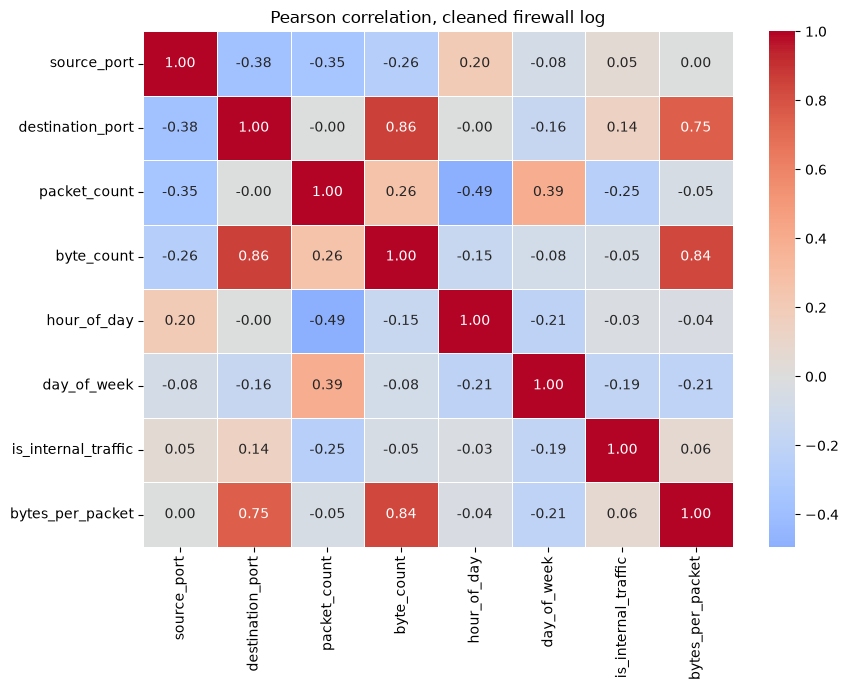

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = clean.select_dtypes(include=np.number)
corr = numeric.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, center=0)
plt.title('Pearson correlation, cleaned firewall log')
plt.tight_layout(); plt.show()

**Task 1.4 — write-up.**

1. Which pair of features is most strongly correlated, and is that surprising given how you
   built them?
2. `hour_of_day` takes only four distinct values in this dataset. What does that do to any
   correlation you compute with it, and would you trust the number?
3. Normally we drop one of a pair of highly correlated features. Here we are keeping
   everything. Given the size of this dataset, argue whether that is defensible.

**[insert response]**

## Lab 1.5 — Prepare for modelling

Three steps, in a fixed order, and the order is the point.

1. **Drop what you cannot use.** `timestamp`, `source_ip` and `destination_ip` are text or
   dates; you already extracted their value into features. Drop them.
2. **Encode the text.** One-hot encode `protocol`, `firewall_rule` and `device_type`. Label
   encode `threat_type` into integers.
3. **Split, then scale.** Fit the scaler on the training data *only*, then apply it to both.

> **Why split before scaling.** A scaler computes the minimum and maximum of each column. If
> you fit it on everything, the test rows influence those numbers, and information from your
> test set has leaked into your training pipeline. Your score comes out better than it should
> and you have no way to tell. This is the single most common leak in applied ML, and Module 3
> is largely about the family of mistakes it belongs to.

**Task 1.5.** Do all three. Print the class mapping, the resulting feature count, and the
train/test sizes.

In [ ]:
# --- TASK 1.5 ---
# 1. Drop 'timestamp', 'source_ip', 'destination_ip'.
# 2. One-hot encode 'protocol', 'firewall_rule', 'device_type' (drop_first=True, dtype=int).
#    Label encode 'threat_type' -- .astype('category').cat.codes gives you integers,
#    and .cat.categories gives you the names in the matching order.
# 3. train_test_split with test_size=0.2, random_state=SEED, stratify=y.
# 4. Fit a MinMaxScaler on the TRAINING data only, then transform both.
#
# Name your results X_train_scaled, X_test_scaled, y_train, y_test, X, class_names
# so the cells below work.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# YOUR CODE HERE

## Lab 1.6 — Train, predict, evaluate

predicted: [2 1 0 0 0]
actual   : [2 1 0 0 0]

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00         3
 Brute Force       1.00      1.00      1.00         1
        Scan       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



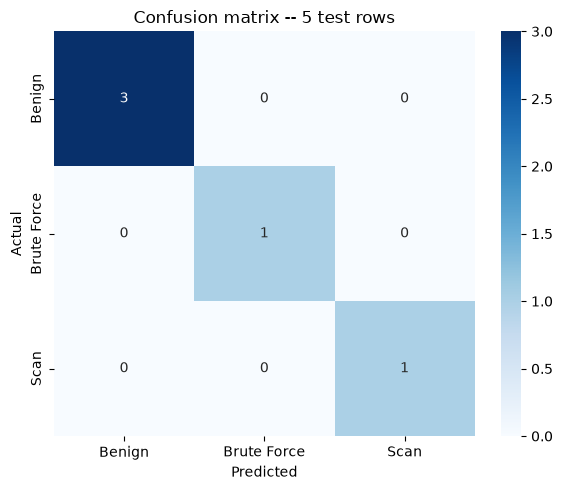

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000, random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("predicted:", y_pred)
print("actual   :", y_test.values)
print()
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion matrix -- 5 test rows')
plt.tight_layout(); plt.show()

## Lab 1.7 — A perfect score is a symptom

Every metric came back **1.00**. Precision, recall, F1, accuracy, all three classes.

In machine learning, a perfect score on the first attempt is not a success. It is a symptom,
and the correct response is to go looking for the cause. There are three candidates and it is
worth ruling them out one at a time.

**Was the process leaky?** No. We split before scaling, so the test rows never influenced the
scaler. That specific mistake was avoided.

**Is the test set big enough to mean anything?** No. Five rows. As noted above, the only
scores this arrangement can produce are multiples of 20%. Getting 5 out of 5 right is roughly
as informative as flipping a coin five times and calling it a trend.

**Did the model find a shortcut?** This is the interesting one, and we can check it directly
rather than speculating.

In [10]:
print("coef_ shape:", model.coef_.shape, " <- one ROW PER CLASS, not one vector")
print()

importance = pd.DataFrame(model.coef_.T, index=X.columns, columns=class_names)

for name in class_names:
    top = importance[name].sort_values(ascending=False).head(4)
    print(f"strongest evidence FOR '{name}':")
    for feat, val in top.items():
        print(f"    {feat:26s} {val:+.3f}")
    print()

coef_ shape: (3, 16)  <- one ROW PER CLASS, not one vector

strongest evidence FOR 'Benign':
    protocol_UDP               +0.465
    source_port                +0.455
    device_type_Laptop         +0.400
    bytes_per_packet           +0.378

strongest evidence FOR 'Brute Force':
    packet_count               +0.981
    device_type_Unknown        +0.812
    firewall_rule_Deny         +0.463
    day_of_week                +0.071

strongest evidence FOR 'Scan':
    device_type_IoT Device     +0.755
    firewall_rule_Deny         +0.566
    hour_of_day                +0.237
    day_of_week                +0.051



### What the coefficients actually say

Read the three lists. The pattern is not subtle:

- **Brute Force** is predicted by `device_type_Unknown` and `firewall_rule_Deny`.
- **Scan** is predicted by `device_type_IoT Device` and `firewall_rule_Deny`.
- **Benign** is predicted by ordinary things — protocol, port, laptop.

Now go back and look at the cleaned data. In these 24 rows:

- **every** brute-force attempt came from a device whose type was missing
- **every** scan came from an IoT device
- **every** attack was denied by the firewall, and **every** benign event was allowed

The model did not learn what a brute-force attack looks like. It learned *"unknown device
type means brute force"*, and *"the firewall already blocked it, so it was bad."*

That second rule is worth sitting with. **The firewall's own verdict is in the feature set.**
We are asking a model to detect threats while handing it a column that says whether the
firewall already caught the threat. It is not detection, it is copying — and it will work
perfectly right up until it meets an attack the firewall allowed, which is the only kind of
attack anybody actually needs a model for.

> **Note for anyone comparing against an earlier version of this notebook:** a previous draft
> explained the perfect score by saying the model had memorised the attacker's IP address,
> `103.27.14.88`. It is true that all seven brute-force rows share that IP — but `source_ip`
> is dropped in Lab 1.5 before the model ever sees it. The model cannot have learned that
> rule. The real shortcut is the one above, and the coefficients are how you tell the
> difference between a plausible story and a true one.

### Memorisation versus generalisation

A model that **memorises** learns the specific artifacts of the examples it was shown. A model
that **generalises** learns a pattern that holds for examples it has never seen.

Ask what happens when this model meets a brute-force attack from a correctly-inventoried
laptop that the firewall allowed through. Every signal it relies on is absent. It will call
that traffic benign, confidently, and it will be wrong — while still reporting 100% accuracy
on the test set you gave it.

**Task 1.7 — write-up.**

1. Of the three shortcuts above, which would be hardest to notice in a production dataset of
   a million rows, and why?
2. `firewall_rule` is the firewall's own decision about the traffic. Make the argument for
   removing it from the feature set — then make the argument for keeping it. Which do you
   find more convincing, and what would change your mind?
3. You cannot make this dataset bigger. Name two things you *could* do to get a more honest
   estimate of how good this model really is.

**[insert response]**

---

# Lab 2: The Same Pipeline, On Real Data

Lab 1 taught you the mechanics on 24 rows you could read by eye. Now do it properly.

In **Module 1** you audited a dataset of 88,647 phishing URLs and found things wrong with it:

| what Module 1 found | scale |
|---|---|
| missing values encoded as `-1` rather than `NaN` | **66 of 111 columns** |
| duplicate rows | **1,438** |
| identical feature vectors carrying **both** labels | 6 vectors, 13 rows |
| columns with only one distinct value | **13** |

Auditing is only half the job. This lab is the other half: **act on the findings, build a
model, and then measure whether acting on them changed anything.**

That last step is the one people skip. It is easy to assume a defect must have mattered. The
honest move is to check.

In [11]:
urls = pd.read_parquet(DATA_URL + "phishing_dataset1.parquet")
print(f"loaded {urls.shape[0]:,} rows x {urls.shape[1]} columns")
print(f"label balance: {urls['phishing'].value_counts().to_dict()}")
print(f"phishing fraction: {urls['phishing'].mean():.3f}")

loaded 88,647 rows x 112 columns
label balance: {0: 58000, 1: 30647}
phishing fraction: 0.346


**Task 2.1.** Apply two of Module 1's findings, then train the same kind of model you
trained in Lab 1:

1. Drop the columns that carry no information (one distinct value).
2. Drop the exact duplicate rows.
3. Split 80/20, stratified, then scale — fitting the scaler on the training set only.
4. Train a `LogisticRegression` and report accuracy, F1, and the classification report.
5. Report the **majority-class baseline** alongside it: the accuracy you would get by always
   guessing the more common class. A model that cannot beat that number has earned nothing.

In [ ]:
# --- TASK 2.1 ---
# 1. Drop the columns with only one distinct value.
# 2. Drop exact duplicate rows.
# 3. Split 80/20 stratified, then scale (fit on train only).
# 4. Train a LogisticRegression(max_iter=2000) and report accuracy and F1.
# 5. Print the majority-class baseline next to your accuracy.
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# YOUR CODE HERE

## Lab 2.2 — Did the cleanup actually help?

You dropped 13 columns and 1,438 rows because Module 1 showed they were defective. It is
natural to assume that helped.

**Task 2.2.** Find out. Train the same model three ways and compare:

1. On the cleaned data (you already have this number).
2. With the 13 constant columns **left in**.
3. With the duplicate rows **left in**.

Predict what you expect before you run it. Then write down what actually happened.

In [ ]:
# --- TASK 2.2 ---
# Train the same model three ways and print accuracy and F1 for each:
#   1. on your cleaned data
#   2. with the 13 constant columns left in
#   3. with the 1,438 duplicate rows left in
#
# Write your prediction down BEFORE you run it.
# Hint: a small helper function that takes a DataFrame and a label keeps this readable.

# YOUR CODE HERE

**Task 2.2 — write-up.**

1. What did you predict, and what happened?
2. Dropping the 13 dead columns changed accuracy by exactly nothing. Explain why a column
   with a single distinct value cannot affect a linear model's predictions.
3. The duplicates made no meaningful difference here either. Describe a dataset or a model
   where the *same* 1,438 duplicates would have mattered enormously.
4. Given all that — was the audit a waste of time? Defend your answer.

**[insert response]**

---

## Module 2 Summary

You did two versions of the same job.

**On 24 rows** you cleaned a genuinely broken log — duplicates, a corrupt timestamp, an
impossible port, four spellings of two firewall verdicts, dates stored as text — engineered
four features from raw fields, trained a classifier, and scored a perfect 100%. Then you
opened up the model and found it had learned that unknown device types mean brute force and
that the firewall's own verdict predicts the answer. A perfect score, worth nothing.

**On 87,209 rows** you acted on an audit from Module 1, trained the same kind of model, and
got **93.35% against a 65.03% baseline**. A worse-looking number that is worth a great deal
more, because the 28-point gap over the baseline is real.

| | Lab 1 (toy log) | Lab 2 (real URLs) |
|---|---|---|
| rows after cleaning | 24 | 87,209 |
| test rows | 5 | 17,442 |
| accuracy | **100%** | 93.35% |
| majority baseline | 60% | 65.03% |
| trustworthy? | no | yes |

Three things to carry forward.

**A number needs a baseline before it means anything.** 93% sounds worse than 100% and is
enormously better. You cannot tell without knowing what guessing would have got you.

**Look inside the model.** The coefficients are how you tell a plausible story from a true
one. In Lab 1 the obvious explanation — that the model memorised the attacker's IP — was
impossible, because that column had been dropped. Only the coefficients showed what really
happened.

**The size of a data defect cannot be reasoned out in advance.** You removed 13 dead columns
and 1,438 duplicate rows and the score did not move. That does not mean audits are pointless;
it means the *magnitude* of a defect is an empirical question. Module 3 shows the same family
of problem costing you a great deal, and Module 4 shows one costing an entire class.

---

## Reflection Questions

**1.** Of the attack types reviewed at the start of this module, which would be hardest to
detect with rule-based tools alone, and what specifically would machine learning add?

**[insert response]**

**2.** You are asked to build detection for a hospital network — medical devices, staff
workstations, patient records. Which of CICIDS2017, EMBER, IoT-23 or PhishTank would you
train on, and what would still be missing?

**[insert response]**

**3.** The Lab 1 model used `firewall_rule` — the firewall's own decision — as a feature. Name
another feature you might find in a real security dataset that leaks the answer in the same
way, and say how you would spot it.

**[insert response]**

**4.** Lab 2's model reached 93.35%. Roughly 7% of URLs are classified wrongly. For a phishing
blocker, which mistake is worse: blocking a legitimate site, or letting a phishing site
through? Justify it, then say how you would change the model's behaviour to reflect your
answer.

**[insert response]**

**5.** Module 1 audited the URL dataset and Module 2 acted on it — and the cleanup changed the
score by almost nothing. Write down what you would tell a colleague who concludes from this
that data auditing is overrated.

**[insert response]**

---

## Reference: cheat sheets

* [pandas cheat sheet (PDF)](https://media.datacamp.com/legacy/image/upload/v1676302204/Marketing/Blog/Pandas_Cheat_Sheet.pdf)
* [scikit-learn cheat sheet](https://www.datacamp.com/cheat-sheet/scikit-learn-cheat-sheet-machine-learning)

The commands that mattered most in this module: `.drop_duplicates()`, `.dropna()`,
`.fillna()`, `pd.to_datetime()`, `.astype()`, `.str.capitalize()`, `pd.get_dummies()`,
`train_test_split()`, `MinMaxScaler` / `StandardScaler`, `LogisticRegression`,
`classification_report()` and `confusion_matrix()`.

###Sources

* https://attack.mitre.org/

* https://docs.sophos.com/central/mdr/help/en-us/welcomeGuides/MDR/mitre/index.html

* https://www.lockheedmartin.com/en-us/capabilities/cyber/cyber-kill-chain.html

* https://medium.com/@denizgunay/feature-engineering-data-preprocessing-d6bc219b6b93

* https://viso.ai/deep-learning/deep-learning-vs-machine-learning/